# Steam 리뷰 긍/부정 워드클라우드 파이프라인

**진행 순서**
1. **E**xtract(실제 크롤러) - Transform - **L**oad (ETL)
2. 데이터 로드
3. 데이터 전처리
4. 긍정/부정 워드클라우드 시각화 (연어(collocation) 처리 포함)

- Extract: `crawler.py`의 `SteamReviewCrawler`로 Steam 리뷰 페이지를 크롤링 (Playwright 필요)
- 저장소: SQLite `meccha.db`

> **주의**: 실제 크롤링에는 Playwright 브라우저와 `steamcommunity.com` 접속 권한이 필요합니다.
> 이미 크롤링해 둔 `output_positive.json` / `output_negative.json` 이 있다면 재크롤링 없이 바로 사용합니다
> (`force_recrawl=False`, 기본값).


## 0. 라이브러리 준비

In [1]:
# 최초 1회 실행 (crawler.py가 필요로 하는 패키지들)
# !pip install playwright beautifulsoup4 lxml wordcloud --quiet
# !playwright install chromium


In [2]:
import os
import json
import re
import sqlite3
from collections import Counter
from multiprocessing import Process

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# crawler.py / schema.py 는 노트북과 같은 폴더에 있어야 합니다.
from crawler import run_crawler, setup_logger

pd.set_option('display.max_colwidth', 100)

# 공통 설정값
APP_ID = 4704690
OUTPUT_DIR = "."          # 크롤링 결과 JSON을 저장/조회할 위치
DB_PATH = "meccha.db"
TABLE_NAME = "reviews"
KEEP_COLS = ["review_id", "sentiment", "review_text", "helpful_count"]


## 1. ETL

### Extract
`crawler.py`의 `SteamReviewCrawler` / `run_crawler`를 그대로 사용해서 긍정/부정 리뷰를
멀티프로세스로 동시에 크롤링합니다. 이미 크롤링 결과 파일이 있으면 (`force_recrawl=False`)
재크롤링 없이 바로 그 파일을 읽어옵니다.


In [3]:
def extract(app_id: int, output_dir: str, target_reviews: int = 2000, force_recrawl: bool = False) -> list:
    """
    Extract: Steam 리뷰 크롤링

    - force_recrawl=False 이고 output_positive.json / output_negative.json 이 이미 있으면
      크롤링을 생략하고 기존 파일을 그대로 읽음
    - 그렇지 않으면 crawler.py의 run_crawler로 긍정/부정 리뷰를 멀티프로세스로 동시에 수집
      (Playwright 브라우저 + steamcommunity.com 접속 필요)
    """
    os.makedirs(output_dir, exist_ok=True)
    positive_path = os.path.join(output_dir, "output_positive.json")
    negative_path = os.path.join(output_dir, "output_negative.json")

    already_crawled = os.path.exists(positive_path) and os.path.exists(negative_path)

    if force_recrawl or not already_crawled:
        print("[Extract] 크롤링을 시작합니다 (Playwright + 네트워크 필요)...")
        setup_logger()

        p_positive = Process(target=run_crawler, args=(app_id, "positive", positive_path))
        p_negative = Process(target=run_crawler, args=(app_id, "negative", negative_path))
        p_positive.start()
        p_negative.start()
        p_positive.join()
        p_negative.join()

        print("[Extract] 크롤링 완료")
    else:
        print("[Extract] 기존 크롤링 결과 파일을 사용합니다 (재크롤링 생략)")

    raw_data = []
    for path in (positive_path, negative_path):
        with open(path, "r", encoding="utf-8") as f:
            raw_data.extend(json.load(f))

    print(f"[Extract] 총 {len(raw_data)}건 로드")
    return raw_data


### Transform
Extract가 반환한 raw 데이터를 DataFrame으로 변환하고,
`review_id`, `sentiment`, `review_text`, `helpful_count` 컬럼만 남깁니다.


In [4]:
def transform(raw_data: list, keep_cols: list) -> pd.DataFrame:
    """Transform: DataFrame으로 변환 후 필요한 컬럼만 선택"""
    df_raw = pd.DataFrame(raw_data)
    df = df_raw[keep_cols].copy()
    print(f"[Transform] 변환 후 shape: {df.shape}")
    return df


### Load
SQLite(`meccha.db`)에 `reviews` 테이블로 저장합니다.


In [5]:
def load(df: pd.DataFrame, db_path: str, table_name: str) -> None:
    """Load: DataFrame을 SQLite DB에 저장"""
    conn = sqlite3.connect(db_path)
    try:
        df.to_sql(table_name, conn, if_exists="replace", index=False)
        conn.commit()
    finally:
        conn.close()
    print(f"[Load] '{db_path}' 에 '{table_name}' 테이블로 {len(df)}건 저장 완료")


In [6]:
def run_etl(app_id: int, output_dir: str, db_path: str, table_name: str, keep_cols: list,
            target_reviews: int = 2000, force_recrawl: bool = False) -> pd.DataFrame:
    """ETL 전체 파이프라인 실행"""
    raw_data = extract(app_id, output_dir, target_reviews=target_reviews, force_recrawl=force_recrawl)
    df = transform(raw_data, keep_cols)
    load(df, db_path, table_name)
    return df


df_etl = run_etl(APP_ID, OUTPUT_DIR, DB_PATH, TABLE_NAME, KEEP_COLS, force_recrawl=False)
df_etl.head()


[Extract] 기존 크롤링 결과 파일을 사용합니다 (재크롤링 생략)
[Extract] 총 4000건 로드
[Transform] 변환 후 shape: (4000, 4)
[Load] 'meccha.db' 에 'reviews' 테이블로 4000건 저장 완료


,review_id,sentiment,review_text,helpful_count
0,https://steamcommunity.com/profiles/76561198830268492/recommended/4704690/,Positive,This game is basically an art contest for the hider and an eye exam for the hunter.,2302
1,https://steamcommunity.com/id/cabalotpt/recommended/4704690/,Positive,1st - Congrats on having an original idea for a game. 2nd - I've been having a lot of fun with i...,3121
2,https://steamcommunity.com/profiles/76561198031356113/recommended/4704690/,Positive,People with art degrees finally have something to exel at. Great game.,794
3,https://steamcommunity.com/profiles/76561198811233852/recommended/4704690/,Positive,"What a fun game, devs have been relentless with the updates as well, have already improved so mu...",464
4,https://steamcommunity.com/id/jrxonfire/recommended/4704690/,Positive,Ultra fun. Couldn't ask more for this price. I'd pay even 10 EUR. Edit: I actually did pay 10 EU...,302


## 2. 데이터 로드

SQLite(`meccha.db`)에서 데이터를 다시 불러옵니다. 이후 단계는 이 함수로 불러온 DataFrame을 사용합니다.


In [7]:
def load_data_from_db(db_path: str, table_name: str) -> pd.DataFrame:
    """DB 로드: SQLite에서 테이블 전체를 읽어 DataFrame으로 반환"""
    conn = sqlite3.connect(db_path)
    try:
        schema = pd.read_sql(f"PRAGMA table_info({table_name})", conn)
        sentiment_counts = pd.read_sql(
            f"SELECT sentiment, COUNT(*) AS cnt FROM {table_name} GROUP BY sentiment", conn
        )
        df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    finally:
        conn.close()

    print(f"[Data Load] '{table_name}' 테이블 로드 완료 - shape: {df.shape}")
    print("[Data Load] 테이블 스키마")
    display(schema)
    print("[Data Load] sentiment 분포")
    display(sentiment_counts)

    return df


df_db = load_data_from_db(DB_PATH, TABLE_NAME)
df_db.sample(5, random_state=42)


[Data Load] 'reviews' 테이블 로드 완료 - shape: (4000, 4)
[Data Load] 테이블 스키마


,cid,name,type,notnull,dflt_value,pk
0,0,review_id,TEXT,0,None,0
1,1,sentiment,TEXT,0,None,0
2,2,review_text,TEXT,0,None,0
3,3,helpful_count,INTEGER,0,None,0


[Data Load] sentiment 분포


,sentiment,cnt
0,Negative,1998
1,Positive,2002


,review_id,sentiment,review_text,helpful_count
555,https://steamcommunity.com/profiles/76561199142499653/recommended/4704690/,Positive,good fun if my bum friends get on the game,0
3491,https://steamcommunity.com/id/DIRTYWALLNUTER/recommended/4704690/,Negative,I DONT LIKE MECCA CHARMELION CUZ IT KEEPS KICKING ME,0
527,https://steamcommunity.com/profiles/76561199074518630/recommended/4704690/,Positive,,0
3925,https://steamcommunity.com/profiles/76561199217517345/recommended/4704690/,Negative,Doesn't start on my computer :(,0
2989,https://steamcommunity.com/profiles/76561198813872887/recommended/4704690/,Negative,There's so many glitches and spots that the hiders can get into but not the seekers. I can't cou...,0


## 3. 데이터 전처리

1. 결측/공백 리뷰 제거
2. 텍스트 정제 (소문자화, URL 제거, 특수문자 제거 - 단, 축약형 부정문(`don't`, `isn't` 등)을 살리기 위해 어퍼스트로피(`'`)는 유지)
3. 감성별 데이터 분리

> 불용어 제거와 연어(collocation) 탐지는 다음 워드클라우드 단계에서 `WordCloud`가 원문 텍스트를 보고 함께 처리합니다.
> `not`, `isn't` 같은 부정어를 여기서 미리 지워버리면 `not fun`처럼 문맥이 있는 표현을 만들 수 없기 때문입니다.


In [8]:
def remove_missing_reviews(df: pd.DataFrame) -> pd.DataFrame:
    """결측치 및 빈 리뷰 제거"""
    df_clean = df.dropna(subset=["review_text", "sentiment"]).copy()
    df_clean["review_text"] = df_clean["review_text"].astype(str).str.strip()
    df_clean = df_clean[df_clean["review_text"] != ""]
    print(f"[전처리] 결측/빈 리뷰 제거: {len(df)}건 -> {len(df_clean)}건")
    return df_clean


def clean_text(text: str) -> str:
    """텍스트 정제: 소문자화, URL 제거, 특수문자/숫자 제거 (어퍼스트로피는 유지)"""
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)   # 부정 축약형 보존을 위해 ' 는 남김
    text = re.sub(r"\s+", " ", text).strip()
    return text


def split_by_sentiment(df: pd.DataFrame):
    """감성별로 DataFrame 분리"""
    df_positive = df[df["sentiment"].str.lower() == "positive"]
    df_negative = df[df["sentiment"].str.lower() == "negative"]
    print(f"[전처리] 긍정 리뷰: {len(df_positive)}건 / 부정 리뷰: {len(df_negative)}건")
    return df_positive, df_negative


def preprocess(df: pd.DataFrame):
    """전처리 파이프라인 전체 실행"""
    df_clean = remove_missing_reviews(df)
    df_clean["clean_text"] = df_clean["review_text"].apply(clean_text)
    df_positive, df_negative = split_by_sentiment(df_clean)
    return df_clean, df_positive, df_negative


df_clean, df_positive, df_negative = preprocess(df_db)
df_clean[["review_text", "clean_text"]].head()


[전처리] 결측/빈 리뷰 제거: 4000건 -> 3994건
[전처리] 긍정 리뷰: 1997건 / 부정 리뷰: 1997건


,review_text,clean_text
0,This game is basically an art contest for the hider and an eye exam for the hunter.,this game is basically an art contest for the hider and an eye exam for the hunter
1,1st - Congrats on having an original idea for a game. 2nd - I've been having a lot of fun with i...,st congrats on having an original idea for a game nd i've been having a lot of fun with it rd pl...
2,People with art degrees finally have something to exel at. Great game.,people with art degrees finally have something to exel at great game
3,"What a fun game, devs have been relentless with the updates as well, have already improved so mu...",what a fun game devs have been relentless with the updates as well have already improved so much...
4,Ultra fun. Couldn't ask more for this price. I'd pay even 10 EUR. Edit: I actually did pay 10 EU...,ultra fun couldn't ask more for this price i'd pay even eur edit i actually did pay eur bought a...


## 4. 워드클라우드 시각화 (연어(collocation) 처리 포함)

- `collocations=True`로 설정하면 `WordCloud`가 원문 텍스트에서 자주 붙어 다니는 두 단어(bigram)를
  하나의 표현으로 묶어줍니다. 예: `not fun`, `so much fun` 처럼 부정어/강조어 + 단어 조합이 살아있으면
  단어 하나만 볼 때보다 문맥을 더 잘 반영할 수 있습니다.
- 이 기능은 미리 계산한 단어 빈도(`generate_from_frequencies`)에는 적용되지 않고,
  원문 텍스트를 그대로 넣는 `generate()`에서만 동작하기 때문에 `generate()`를 사용합니다.
- 부정어(`not`, `no`, `isn't` 등)는 불용어 목록에서 제외해서 연어 탐지 시 사라지지 않도록 했습니다.


In [9]:
# WordCloud 기본 불용어 목록에서 부정어를 제외하고, 도메인 불용어를 추가
NEGATION_WORDS = {
    "no", "not", "nor", "never", "none", "nothing", "cannot",
    "can't", "don't", "doesn't", "didn't", "isn't", "wasn't", "aren't",
    "weren't", "won't", "wouldn't", "couldn't", "shouldn't",
    "hasn't", "haven't", "hadn't", "n't",
}

DOMAIN_STOPWORDS = {"game", "games", "play", "played", "playing"}

CUSTOM_STOPWORDS = (set(STOPWORDS) - NEGATION_WORDS) | DOMAIN_STOPWORDS


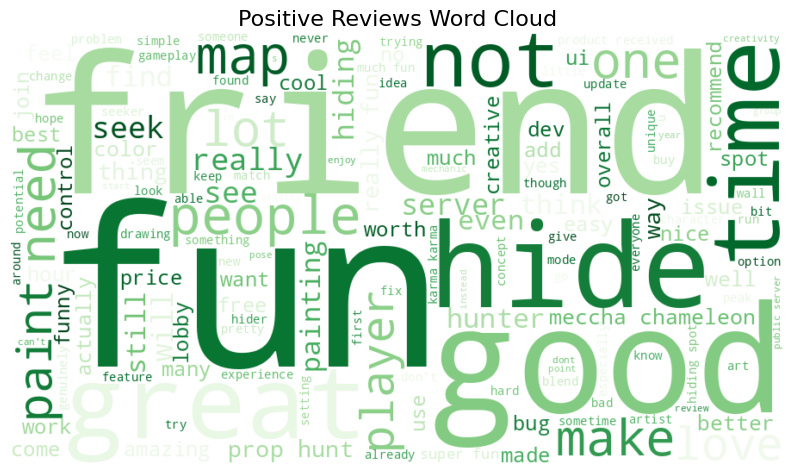

긍정 리뷰 상위 단어 TOP 10
  fun: 1.0
  friend: 0.729
  good: 0.555
  hide: 0.323
  great: 0.301
  time: 0.263
  not: 0.263
  people: 0.232
  map: 0.226
  make: 0.201


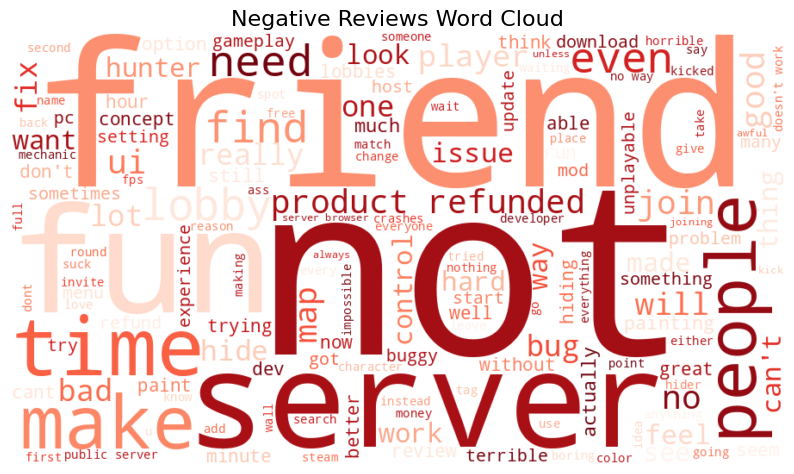

부정 리뷰 상위 단어 TOP 10
  not: 1.0
  friend: 0.877
  fun: 0.842
  server: 0.711
  time: 0.583
  make: 0.466
  people: 0.413
  lobby: 0.364
  even: 0.344
  find: 0.34


In [10]:
def build_wordcloud(text: str, title: str, colormap: str, stopwords: set) -> dict:
    """원문 텍스트로부터 연어(collocation)를 반영한 워드클라우드를 그리고, 단어(구) 빈도를 반환"""
    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        colormap=colormap,
        max_words=150,
        stopwords=stopwords,
        collocations=True,          # 연어(collocation) 처리
        collocation_threshold=10,   # 값이 작을수록 더 많은 두 단어 조합을 연어로 인정
    ).generate(text)

    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

    return wc.words_


def print_top_words(freq: dict, label: str, top_n: int = 10) -> None:
    """상위 빈도 단어(구) 출력"""
    print(f"{label} 상위 단어 TOP {top_n}")
    for word, cnt in Counter(freq).most_common(top_n):
        print(f"  {word}: {round(cnt, 3)}")


def generate_sentiment_wordclouds(df_positive: pd.DataFrame, df_negative: pd.DataFrame, stopwords: set = CUSTOM_STOPWORDS):
    """긍정/부정 워드클라우드를 한 번에 생성"""
    positive_text = " ".join(df_positive["clean_text"])
    negative_text = " ".join(df_negative["clean_text"])

    positive_freq = build_wordcloud(positive_text, "Positive Reviews Word Cloud", "Greens", stopwords)
    print_top_words(positive_freq, "긍정 리뷰")

    negative_freq = build_wordcloud(negative_text, "Negative Reviews Word Cloud", "Reds", stopwords)
    print_top_words(negative_freq, "부정 리뷰")

    return positive_freq, negative_freq


positive_freq, negative_freq = generate_sentiment_wordclouds(df_positive, df_negative)


## 요약

| 단계 | 함수 | 역할 |
|---|---|---|
| ETL | `extract`, `transform`, `load`, `run_etl` | 실제 크롤링(or 기존 결과 재사용) → 컬럼 정리 → SQLite 저장 |
| 데이터 로드 | `load_data_from_db` | `meccha.db`에서 데이터 재로드 + 스키마/분포 확인 |
| 전처리 | `remove_missing_reviews`, `clean_text`, `split_by_sentiment`, `preprocess` | 정제 → 감성 분리 |
| 워드클라우드 | `build_wordcloud`, `print_top_words`, `generate_sentiment_wordclouds` | `collocations=True`로 연어 반영한 긍정/부정 워드클라우드 시각화 |

**`extract()`가 이제 진짜로 Extract 역할을 합니다.**
- 크롤링 결과 파일이 없거나 `force_recrawl=True`이면 `crawler.py`의 `run_crawler`를 멀티프로세스로 실행해 실제 크롤링 수행
- 이미 크롤링 결과가 있으면 그 파일을 그대로 읽어 반환
- `run_etl()`은 언제나 `extract() -> transform() -> load()` 흐름만 유지하면 되고, 크롤링 로직이 바뀌어도 `run_etl()`을 건드릴 필요가 없습니다.
